In [1]:
using Revise

In [2]:
using GeneRegulatorySystems
using GeneRegulatorySystems.Models
using GeneRegulatorySystems.Models.NetworkRepresentation
using GeneRegulatorySystems.Models.V1
using GeneRegulatorySystems.Scheduling
import JSON
using GarishPrint

macro pp(x) :(GarishPrint.pprint($(esc(x)))) end;

Load schedule

In [20]:
path_diff = "examples/specification/differentiation.schedule.json"
path_v1 = "examples/toy/ACDC.schedule.json"
path_kronecker = "examples/benchmark/kronecker-small.schedule.json"
path_rand_diff = "examples/specification/random-differentiation.schedule.json"

schedule! = Models.load(path_v1, seed="seed123");

In [42]:
f! = Scheduling.reify(schedule!, "-2-1+-1+")

GeneRegulatorySystems.Models.Scheduling.Primitive(GeneRegulatorySystems.Models.Wrapped{GeneRegulatorySystems.Models.SciML.JumpState}(GeneRegulatorySystems.Models.Scheduling.Locator("-2-1+-1.do"), GeneRegulatorySystems.Models.Wrapped{GeneRegulatorySystems.Models.SciML.JumpState}(GeneRegulatorySystems.Models.V1.Definition(:polymerases, :ribosomes, :proteasomes, GeneRegulatorySystems.Models.V1.Gene[GeneRegulatorySystems.Models.V1.Gene{GeneRegulatorySystems.Models.V1.EukaryoteBaseRates}(Symbol("1"), GeneRegulatorySystems.Models.V1.EukaryoteBaseRates(2.5, 10.0, 6.6e-7, 0.001, 0.02, 2.5e-9, 0.01, 0.001, 0.001, 3.0e-10), true, GeneRegulatorySystems.Models.V1.Activation(GeneRegulatorySystems.Models.V1.HillRegulator[GeneRegulatorySystems.Models.V1.HillRegulator(Symbol("1"), 2.0, -1.0)], minimum), GeneRegulatorySystems.Models.V1.Repression(GeneRegulatorySystems.Models.V1.HillRegulator[GeneRegulatorySystems.Models.V1.HillRegulator(Symbol("3"), 4.0, -1.0)], minimum), GeneRegulatorySystems.Models.V

In [53]:
rs = f!.f!.model.model.definition

Model reaction_system:
Unknowns (18): see unknowns(reaction_system)
  var"1₊active"(t)
  var"1₊proteins"(t)
  var"3₊proteins"(t)
  var"2₊active"(t)
  ⋮
Parameters (24): see parameters(reaction_system)
  var"1₊trigger"
  var"1₊transcription"
  var"1₊processing"
  var"1₊translation"
  ⋮

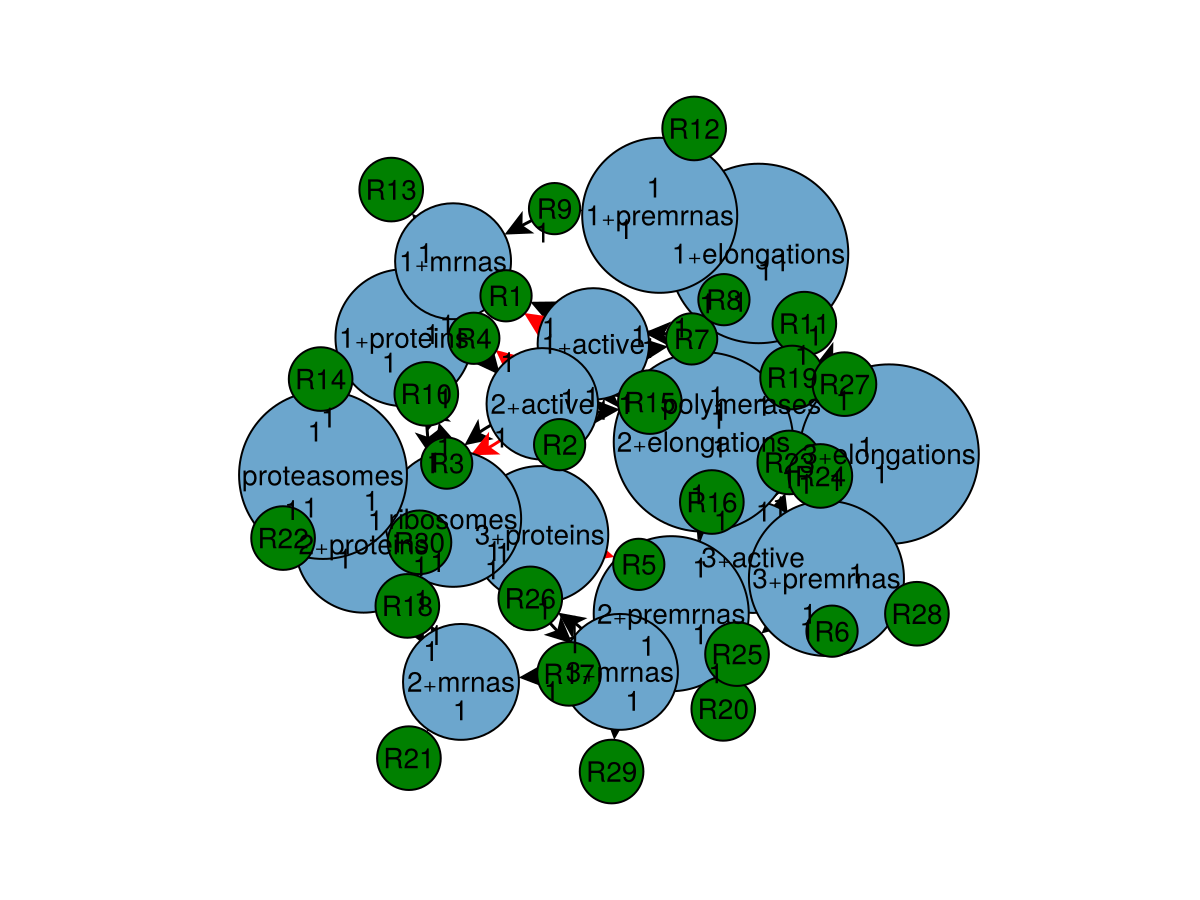

In [56]:
using Catalyst
using GraphMakie
using NetworkLayout
using CairoMakie

Catalyst.plot_network(rs)

Reify the schedule. Need to do a dryrun to get all the primitives

In [ ]:
# this only extracts the first network that it finds in the schedule, rather than all of them
function extract_network(schedule::Scheduling.Schedule)
    network = nothing
    
    function dryrun_collector(primitive!, x, Δt; path, _...)
        if !(isfinite(Δt) && Δt > 0.0)
            return
        end
        if network === nothing
            network = Models.NetworkRepresentation.entity(primitive!)
        end
    end
    
    schedule(Models.FlatState(); dryrun=dryrun_collector)
    return network
end

network = extract_network(schedule!)

In [ ]:
schedule_files = [
    "examples/specification/differentiation.schedule.json",
    "examples/benchmark/differentiated-small.schedule.json",
    "examples/benchmark/differentiated-medium.schedule.json",
    "examples/benchmark/kronecker-tiny.schedule.json",
    "examples/benchmark/kronecker-small.schedule.json",
    "examples/benchmark/kronecker-medium.schedule.json",
    "examples/benchmark/kronecker-big.schedule.json",
    #"examples/benchmark/kronecker-huge.schedule.json",
]

results = Dict()
timings = Dict()

for path in schedule_files
    try
        @info "Processing: $path"
        elapsed = @elapsed begin
            sched = Models.load(path, seed="seed123")
            net = extract_network(sched)
        end
        
        if net !== nothing
            flat_nodes, flat_links = NetworkRepresentation.flatten(net)
            num_nodes = length(flat_nodes)
            num_links = length(flat_links)
            @info "  Success: $(num_nodes) nodes, $(num_links) links ($(round(elapsed, digits=3))s)"
            results[path] = "Success (nodes=$num_nodes, links=$num_links)"
            timings[path] = (time=elapsed, nodes=num_nodes)
        else
            @warn "  Failed: network is nothing"
            results[path] = "Failed"
            timings[path] = (time=elapsed, nodes=0)
        end
    catch e
        @error "  Error: $e"
        results[path] = "Error: $(e)"
        timings[path] = (time=NaN, nodes=0)
    end
end

In [ ]:
using CairoMakie

nodes_list = [timings[path].nodes for path in schedule_files if !isnan(timings[path].time)]
times_list = [timings[path].time for path in schedule_files if !isnan(timings[path].time)]
labels_list = [splitdir(path)[2] for path in schedule_files if !isnan(timings[path].time)]

fig = Figure(size=(1000, 600))
ax = Axis(fig[1, 1], xlabel="Number of Nodes", ylabel="Time (s)", 
          title="Processing Time vs Network Size")

scatter!(ax, nodes_list, times_list, markersize=10, color=:blue, alpha=0.6)

for (x, y, label) in zip(nodes_list, times_list, labels_list)
    text!(ax, x, y + 0.01, text=label, fontsize=9)
end

fig